# Chapter 8: Causal-Loop Diagrams Without Causal Theater

*Systems Thinking with AI* by Jason Karpeles

A diagram is a list of claims, and each claim can be counted, audited and removed.

**Goal.** Four small experiments with a causal graph held as a list of links. Count negative links to find a loop's polarity, audit which arrows rest on assumption, add one arrow and count the loops it closes, and remove the weakest arrow to see which loops stop closing.

**Demonstrations**

1. Two negative links make a reinforcing loop
2. An audit counts what the picture rests on
3. One more arrow closes loops nobody counted
4. Remove the weakest arrow

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/08-causal-graph/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/08-causal-graph/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_08_causal_graph/code/graph.py`

In [2]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 8 reader: a causal-loop diagram as a list of links that can be counted and audited.

Every number comes from the Chapter 8 pack (Link, find_loops, loop_polarity, audit) so the reader,
the pack and the book agree.
"""
from __future__ import annotations

from matplotlib.patches import FancyArrowPatch
from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_08_causal_graph.code.graph import (
    Link,
    audit,
    find_loops,
    links_without_time_semantics,
    loop_polarity,
    unsupported_links,
)

EQ_POLARITY = 'loop_polarity(["overtime", "morale"], links)'
EQ_AUDIT = "audit(links)"

EVIDENCE_COLOR = {
    "observed": PALETTE["navy"],
    "inferred": PALETTE["teal"],
    "assumed": PALETTE["gold"],
    "proposed": PALETTE["terracotta"],
}
SIGN = {1: "+", -1: "-"}
LABEL_OF = {1: "same direction (+)", -1: "opposite direction (-)"}


def _sign_text(polarity):
    return "(+)" if polarity > 0 else "(-)"


def draw_graph(ax, links, positions, rads=None, label_offsets=None, removed=()):
    """Draw nodes and arrows. Colour is the evidence level, dashed means no recorded time semantics."""
    rads = rads or {}
    label_offsets = label_offsets or {}
    for name, (x, y) in positions.items():
        ax.text(x, y, name, ha="center", va="center", fontsize=11, color=PALETTE["ink"], zorder=5,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=PALETTE["grey"], linewidth=1.2))
    for link in links:
        key = (link.source, link.target)
        (x1, y1), (x2, y2) = positions[link.source], positions[link.target]
        rad = rads.get(key, -0.5)
        style = "dashed" if link.delayed is None else "solid"
        arrow = FancyArrowPatch((x1, y1), (x2, y2), connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>",
                                mutation_scale=16, shrinkA=26, shrinkB=26, linewidth=2,
                                linestyle=style, color=EVIDENCE_COLOR[link.evidence], zorder=2)
        ax.add_patch(arrow)
        dx, dy = label_offsets.get(key, (0.0, 0.0))
        apex_x = (x1 + x2) / 2 + 0.5 * rad * (y2 - y1)
        apex_y = (y1 + y2) / 2 - 0.5 * rad * (x2 - x1)
        side = 1 if apex_y >= (y1 + y2) / 2 else -1
        ax.text(apex_x + dx, apex_y + dy + side * 0.17, f"{_sign_text(link.polarity)} {link.evidence}",
                ha="center", va="center", fontsize=10, color=EVIDENCE_COLOR[link.evidence], zorder=4,
                bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="none"))
    for (src, dst) in removed:
        (x1, y1), (x2, y2) = positions[src], positions[dst]
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), connectionstyle="arc3,rad=-0.5", arrowstyle="-",
                                     shrinkA=26, shrinkB=26, linewidth=1.5, linestyle="dotted",
                                     color=PALETTE["light"], zorder=1))
    ax.set_axis_off()


def _chain_positions():
    return {"backlog": (0.0, 0.0), "production": (1.0, 0.0), "inventory": (2.0, 0.0), "shipments": (3.0, 0.0)}


def _base_links(evidence5="assumed", evidence6="proposed", delayed56=None, flip_inventory_production=False):
    inv_prod = 1 if flip_inventory_production else -1
    return [
        Link("backlog", "production", 1, "observed", delayed=True),
        Link("production", "backlog", -1, "observed", delayed=True),
        Link("production", "inventory", 1, "observed", delayed=True),
        Link("inventory", "production", inv_prod, "inferred", delayed=True),
        Link("inventory", "shipments", 1, evidence5, delayed=delayed56),
        Link("shipments", "inventory", -1, evidence6, delayed=delayed56),
    ]


def _loop_text(loop):
    return " > ".join(loop + [loop[0]])


# Demonstration 1: two negative links make a reinforcing loop.

def two_link_loop(overtime_to_morale=-1, morale_to_overtime=-1):
    a, b = int(overtime_to_morale), int(morale_to_overtime)
    links = [
        Link("overtime", "morale", a, "inferred", False),
        Link("morale", "overtime", b, "inferred", True),
    ]
    kind = loop_polarity(["overtime", "morale"], links)
    negatives = sum(1 for link in links if link.polarity < 0)

    fig, ax = new_figure()
    positions = {"overtime": (0.0, 0.0), "morale": (2.0, 0.0)}
    draw_graph(ax, links, positions, rads={("overtime", "morale"): -0.6, ("morale", "overtime"): -0.6},
               label_offsets={})
    ax.set_xlim(-0.8, 2.8)
    ax.set_ylim(-1.2, 1.2)
    ax.text(1.0, -1.0, f"{kind.capitalize()} loop", ha="center", va="center", fontsize=13,
            color=PALETTE["terracotta"] if kind == "balancing" else PALETTE["navy"])

    product = a * b
    metrics = {
        "Overtime to morale": LABEL_OF[a],
        "Morale to overtime": LABEL_OF[b],
        "Negative links in the loop": negatives,
        "Loop polarity": kind,
    }
    parity = "even" if negatives % 2 == 0 else "odd"
    interpretation = (
        f"Count the negative links: {1 if a < 0 else 0} + {1 if b < 0 else 0} = {negatives}, which is {parity}. "
        f"The product of the signs gives the same answer, {signed(a, 0)} x {signed(b, 0)} = {signed(product, 0)}, "
        f"so the loop is {kind}. "
        + ("Zero negative links also counts as even, so the loop is reinforcing." if negatives == 0 else
           "Two negatives make a reinforcing loop, a spiral rather than a correction." if negatives == 2 else
           "One negative link makes the loop push back toward where it was.")
    )
    return fig, metrics, interpretation


# Demonstration 2: the audit counts what a diagram rests on.

def audit_picture(evidence_inventory_to_shipments="assumed", evidence_shipments_to_inventory="proposed",
                  time_record="unrecorded"):
    delayed56 = None if time_record == "unrecorded" else False
    links = _base_links(evidence_inventory_to_shipments, evidence_shipments_to_inventory, delayed56)
    result = audit(links)

    fig, (left, right) = new_figure(ncols=2)
    pos = {"backlog": (0.0, 0.0), "production": (1.0, 0.0), "inventory": (2.0, 0.0), "shipments": (3.0, 0.0)}
    draw_graph(left, links, pos, rads={k: -0.5 for k in [(l.source, l.target) for l in links]})
    left.set_xlim(-0.5, 3.5)
    left.set_ylim(-1.3, 1.3)
    left.set_title("Dashed: time effect not recorded", fontsize=11)
    names = ["links", "loops", "unsupported", "no_time_semantics"]
    shown = ["Links", "Loops", "Resting on assumption or proposal", "Without time semantics"]
    values = [result[n] for n in names]
    right.barh(range(4), values, color=[PALETTE["navy"], PALETTE["teal"], PALETTE["terracotta"], PALETTE["gold"]], height=0.55)
    for i, v in enumerate(values):
        right.annotate(str(v), (v, i), xytext=(5, 0), textcoords="offset points", va="center", fontsize=11)
    right.set_yticks(range(4), ["Links", "Loops", "Unsupported", "No time\nsemantics"])
    right.invert_yaxis()
    right.set_xlim(0, 7.5)
    right.set_xlabel("Count in the audit")
    right.set_ylabel("Audit field")

    metrics = {
        "Links": result["links"], "Loops": result["loops"], "Reinforcing": result["reinforcing"],
        "Balancing": result["balancing"], "Unsupported": result["unsupported"],
        "No time semantics": result["no_time_semantics"],
    }
    u5 = 1 if evidence_inventory_to_shipments in ("assumed", "proposed") else 0
    u6 = 1 if evidence_shipments_to_inventory in ("assumed", "proposed") else 0
    t5 = 1 if delayed56 is None else 0
    interpretation = (
        f"Unsupported arrows are those resting on assumption or proposal: {u5} (inventory to shipments is "
        f"{evidence_inventory_to_shipments}) + {u6} (shipments to inventory is {evidence_shipments_to_inventory}) = "
        f"{result['unsupported']}. Arrows with no recorded time semantics: {t5} + {t5} = {result['no_time_semantics']}. "
        f"The loop count is unchanged at {result['loops']}, all {result['balancing']} balancing, because evidence "
        f"and timing notes do not alter the signs."
    )
    return fig, metrics, interpretation


# Demonstration 3: an extra arrow creates loops nobody counted by eye.

EXTRAS = {
    "shipments to backlog": ("shipments", "backlog"),
    "inventory to backlog": ("inventory", "backlog"),
    "production to shipments": ("production", "shipments"),
}


def extra_arrow(extra="shipments to backlog", polarity=1):
    src, dst = EXTRAS[extra]
    p = int(polarity)
    base = _base_links()
    extra_link = Link(src, dst, p, "assumed")
    links = base + [extra_link]
    loops = find_loops(links)
    before = find_loops(base)
    new_loops = [loop for loop in loops if loop not in before]
    result = audit(links)

    fig, ax = new_figure()
    pos = _chain_positions()
    rads = {(l.source, l.target): -0.5 for l in base}
    if extra == "shipments to backlog":
        rads[(src, dst)] = -0.75
        offs = {}
    elif extra == "inventory to backlog":
        rads[(src, dst)] = -1.1
        offs = {}
    else:
        rads[(src, dst)] = -1.1
        offs = {}
    draw_graph(ax, links, pos, rads=rads, label_offsets=offs)
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-1.7, 1.7)

    metrics = {
        "Extra arrow": f"{extra} ({SIGN[p]})",
        "Loops before": len(before),
        "Loops after": len(loops),
        "New loops": len(new_loops),
        "Reinforcing": result["reinforcing"],
        "Balancing": result["balancing"],
    }
    descr = "; ".join(f"{_loop_text(loop)} is {loop_polarity(loop, links)}" for loop in new_loops)
    interpretation = (
        f"Before the extra arrow there are {len(before)} loops. Adding {extra} closes {len(new_loops)} more: "
        f"{descr}. Total {len(before)} + {len(new_loops)} = {len(loops)}. Reinforcing {result['reinforcing']}, "
        f"balancing {result['balancing']}, summing to {result['reinforcing']} + {result['balancing']} = {len(loops)}. "
        f"One drawn arrow can add loops that were never discussed, which is why the loops are enumerated by "
        f"code rather than by eye."
    )
    return fig, metrics, interpretation


# Demonstration 4: remove the weakest arrow and see which loops stop closing.

REMOVABLE = {
    "none": None,
    "inventory to shipments": ("inventory", "shipments"),
    "shipments to inventory": ("shipments", "inventory"),
}


def remove_arrow(removed="none", flip="negative"):
    full = _base_links(flip_inventory_production=(flip == "positive"))
    drop = REMOVABLE[removed]
    kept = [l for l in full if (l.source, l.target) != drop]
    before = audit(full)
    result = audit(kept)
    lost = [loop for loop in find_loops(full) if loop not in find_loops(kept)]

    fig, ax = new_figure()
    draw_graph(ax, kept, _chain_positions(), removed=[drop] if drop else [])
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-1.3, 1.3)
    ax.set_title("Dotted grey: arrow removed" if drop else "No arrow removed", fontsize=11)

    metrics = {
        "Arrow removed": removed,
        "Links": result["links"],
        "Loops": result["loops"],
        "Reinforcing": result["reinforcing"],
        "Balancing": result["balancing"],
        "Unsupported": result["unsupported"],
        "No time semantics": result["no_time_semantics"],
    }
    if drop:
        closing = f"The loop {_loop_text(lost[0])} no longer closes." if lost else "No loop is lost."
    else:
        closing = "Nothing is removed, so this is the full diagram."
    interpretation = (
        f"Loops: {before['loops']} - {len(lost)} = {result['loops']}. Unsupported arrows: {before['unsupported']} "
        f"- {before['unsupported'] - result['unsupported']} = {result['unsupported']}. {closing} "
        f"With inventory to production {flip}, the production and inventory loop has "
        f"{'one negative link, so it is balancing' if flip == 'negative' else 'no negative link, so it is reinforcing'}. "
        f"Reinforcing {result['reinforcing']} + balancing {result['balancing']} = {result['loops']}."
    )
    return fig, metrics, interpretation


## 1. Two negative links make a reinforcing loop

*If both links in a loop describe opposition, is the loop balancing?*

Going once around the loop multiplies the signs. Two negatives multiply to a positive, so a disturbance comes back in the direction it started. One negative returns it reversed.

    loop_polarity(["overtime", "morale"], links)

**Symbols and inputs.** Each link has a polarity: +1 when source and target move in the same direction, -1 when they move in opposite directions. A loop is reinforcing when it holds an even number of negative links, and balancing when the number is odd.

**Predict first.** With overtime lowering morale and morale lowering overtime, is the loop reinforcing or balancing?

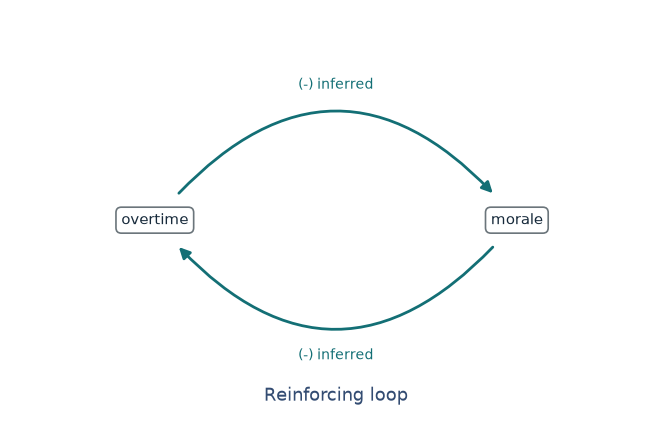

- **Overtime to morale:** opposite direction (-)
- **Morale to overtime:** opposite direction (-)
- **Negative links in the loop:** 2
- **Loop polarity:** reinforcing

Count the negative links: 1 + 1 = 2, which is even. The product of the signs gives the same answer, (-1) x (-1) = 1, so the loop is reinforcing. Two negatives make a reinforcing loop, a spiral rather than a correction.

In [5]:
show(two_link_loop(overtime_to_morale=-1, morale_to_overtime=-1))

**Use the idea.** Before calling a loop a correction, count its negative links rather than relying on the impression that each link opposes something.

**Where the conclusion applies.** Each polarity holds all else constant, and the horizon is the same for both links. The rule says nothing about how fast the loop acts or whether it settles.

*Constructed example: the chapter's overtime and morale pair, with polarities varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(two_link_loop, [('overtime_to_morale', [-1, 1]), ('morale_to_overtime', [-1, 1])])

- **overtime_to_morale = -1, morale_to_overtime = -1**: Overtime to morale opposite direction (-); Morale to overtime opposite direction (-); Negative links in the loop 2; Loop polarity reinforcing
- **overtime_to_morale = -1, morale_to_overtime = 1**: Overtime to morale opposite direction (-); Morale to overtime same direction (+); Negative links in the loop 1; Loop polarity balancing
- **overtime_to_morale = 1, morale_to_overtime = -1**: Overtime to morale same direction (+); Morale to overtime opposite direction (-); Negative links in the loop 1; Loop polarity balancing
- **overtime_to_morale = 1, morale_to_overtime = 1**: Overtime to morale same direction (+); Morale to overtime same direction (+); Negative links in the loop 0; Loop polarity reinforcing

## 2. An audit counts what the picture rests on

*How many arrows in a six-arrow diagram lack observation or a recorded time effect?*

The audit reads fields stored beside each sign. Changing the evidence level or recording a delay changes the unsupported and time counts but not the loops, because loops come from which links exist and from their signs.

    audit(links)

**Symbols and inputs.** Each link is tagged observed, inferred, assumed or proposed. Assumed and proposed links count as unsupported. A link whose delay is unrecorded has no time semantics.

**Predict first.** If inventory to shipments is upgraded from assumed to observed, how many arrows are unsupported?

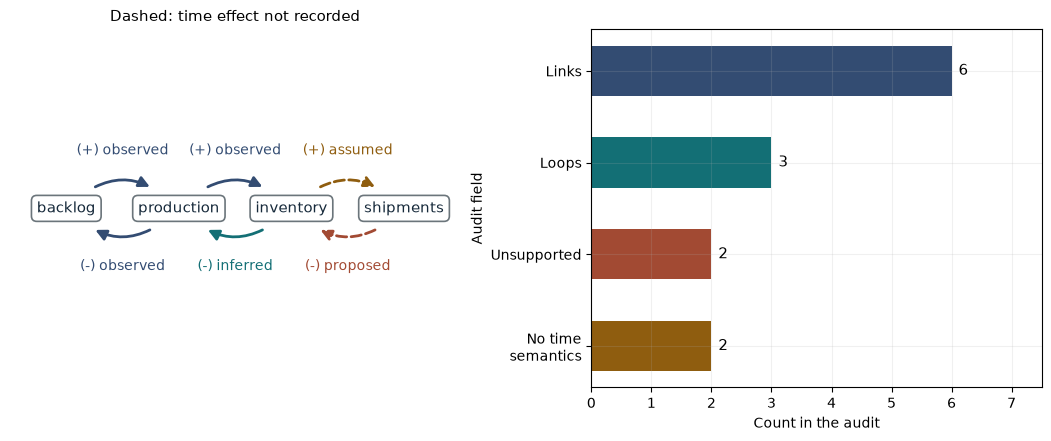

- **Links:** 6
- **Loops:** 3
- **Reinforcing:** 0
- **Balancing:** 3
- **Unsupported:** 2
- **No time semantics:** 2

Unsupported arrows are those resting on assumption or proposal: 1 (inventory to shipments is assumed) + 1 (shipments to inventory is proposed) = 2. Arrows with no recorded time semantics: 1 + 1 = 2. The loop count is unchanged at 3, all 3 balancing, because evidence and timing notes do not alter the signs.

In [7]:
show(audit_picture(evidence_inventory_to_shipments='assumed', evidence_shipments_to_inventory='proposed', time_record='unrecorded'))

**Use the idea.** Keep an evidence record under every diagram, so the mixture of observed and assumed arrows is visible to the audience.

**Where the conclusion applies.** Four evidence levels as the chapter defines them, and a graph of exactly these six links. An observed label is only as good as the record behind it.

*Constructed example: the chapter's six links and its printed audit, with evidence levels and time records varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(audit_picture, [('evidence_inventory_to_shipments', ['assumed', 'observed']), ('evidence_shipments_to_inventory', ['proposed', 'inferred']), ('time_record', ['unrecorded', 'recorded'])])

- **evidence_inventory_to_shipments = assumed, evidence_shipments_to_inventory = proposed, time_record = unrecorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 2; No time semantics 2
- **evidence_inventory_to_shipments = assumed, evidence_shipments_to_inventory = proposed, time_record = recorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 2; No time semantics 0
- **evidence_inventory_to_shipments = assumed, evidence_shipments_to_inventory = inferred, time_record = unrecorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 1; No time semantics 2
- **evidence_inventory_to_shipments = assumed, evidence_shipments_to_inventory = inferred, time_record = recorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 1; No time semantics 0
- **evidence_inventory_to_shipments = observed, evidence_shipments_to_inventory = proposed, time_record = unrecorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 1; No time semantics 2
- **evidence_inventory_to_shipments = observed, evidence_shipments_to_inventory = proposed, time_record = recorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 1; No time semantics 0
- **evidence_inventory_to_shipments = observed, evidence_shipments_to_inventory = inferred, time_record = unrecorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 0; No time semantics 2
- **evidence_inventory_to_shipments = observed, evidence_shipments_to_inventory = inferred, time_record = recorded**: Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 0; No time semantics 0

## 3. One more arrow closes loops nobody counted

*How many feedback loops does a diagram have after one more arrow is drawn?*

A new arrow from a downstream variable to an upstream one closes a path through every arrow between them. Its sign decides whether each newly closed loop reinforces or balances.

    audit(links)

**Symbols and inputs.** A loop is a closed path that follows the arrows and visits each variable once. Each loop is reported once. The extra arrow is tagged assumed.

**Predict first.** After adding shipments to backlog, are there more or fewer than 3 loops?

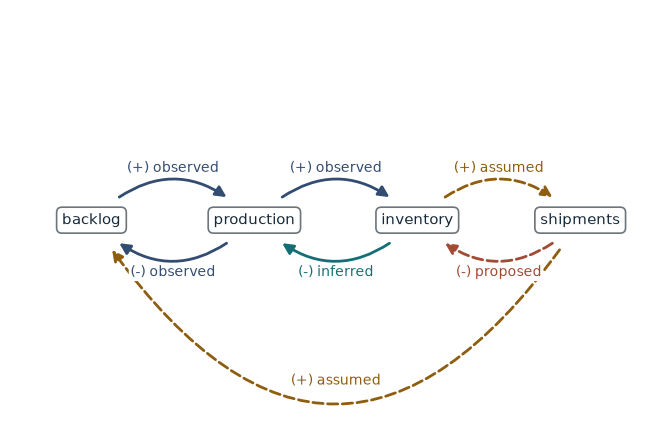

- **Extra arrow:** shipments to backlog (+)
- **Loops before:** 3
- **Loops after:** 4
- **New loops:** 1
- **Reinforcing:** 1
- **Balancing:** 3

Before the extra arrow there are 3 loops. Adding shipments to backlog closes 1 more: backlog > production > inventory > shipments > backlog is reinforcing. Total 3 + 1 = 4. Reinforcing 1, balancing 3, summing to 1 + 3 = 4. One drawn arrow can add loops that were never discussed, which is why the loops are enumerated by code rather than by eye.

In [9]:
show(extra_arrow(extra='shipments to backlog', polarity=1))

**Use the idea.** When someone adds an arrow to a shared diagram, enumerate the loops it creates before agreeing to it.

**Where the conclusion applies.** Only the loops of this seven-arrow graph, and a sign that holds all else constant. Loop strength and delay length are not in the count.

*Constructed example: the chapter's six links plus one extra arrow chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(extra_arrow, [('extra', ['shipments to backlog', 'inventory to backlog', 'production to shipments']), ('polarity', [1, -1])])

- **extra = shipments to backlog, polarity = 1**: Extra arrow shipments to backlog (+); Loops before 3; Loops after 4; New loops 1; Reinforcing 1; Balancing 3
- **extra = shipments to backlog, polarity = -1**: Extra arrow shipments to backlog (-); Loops before 3; Loops after 4; New loops 1; Reinforcing 0; Balancing 4
- **extra = inventory to backlog, polarity = 1**: Extra arrow inventory to backlog (+); Loops before 3; Loops after 4; New loops 1; Reinforcing 1; Balancing 3
- **extra = inventory to backlog, polarity = -1**: Extra arrow inventory to backlog (-); Loops before 3; Loops after 4; New loops 1; Reinforcing 0; Balancing 4
- **extra = production to shipments, polarity = 1**: Extra arrow production to shipments (+); Loops before 3; Loops after 4; New loops 1; Reinforcing 1; Balancing 3
- **extra = production to shipments, polarity = -1**: Extra arrow production to shipments (-); Loops before 3; Loops after 4; New loops 1; Reinforcing 0; Balancing 4

## 4. Remove the weakest arrow

*Which loops stop closing when the least supported arrow is deleted?*

Each loop is a closed path, so deleting any one arrow on it opens the loop. Deleting an unsupported arrow also lowers the unsupported count, but the picture's other loops stay.

    audit(links)

**Symbols and inputs.** The full diagram has six links. Removing an arrow breaks every loop that uses it. Inventory to production is negative in the chapter's diagram; the control can make it positive.

**Predict first.** If shipments to inventory (proposed) is removed, how many loops remain?

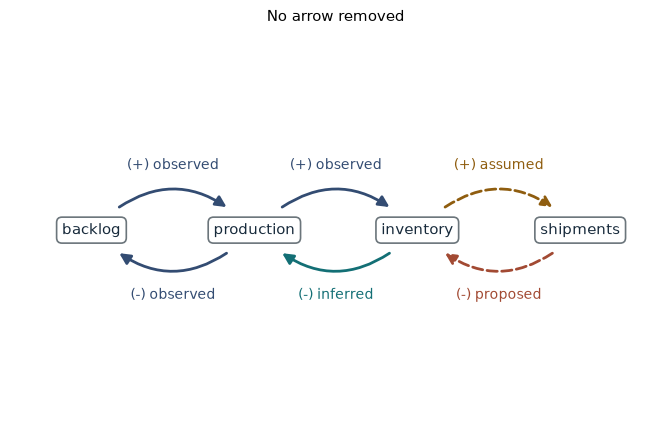

- **Arrow removed:** none
- **Links:** 6
- **Loops:** 3
- **Reinforcing:** 0
- **Balancing:** 3
- **Unsupported:** 2
- **No time semantics:** 2

Loops: 3 - 0 = 3. Unsupported arrows: 2 - 0 = 2. Nothing is removed, so this is the full diagram. With inventory to production negative, the production and inventory loop has one negative link, so it is balancing. Reinforcing 0 + balancing 3 = 3.

In [11]:
show(remove_arrow(removed='none', flip='negative'))

**Use the idea.** Delete the weakest arrow, write what would justify restoring it and who would hold that evidence, then see whether the conclusion changes.

**Where the conclusion applies.** Loops are counted from the links listed. Whether the diagram's conclusion survives depends on what it concluded, which the count cannot say.

*Constructed example: the chapter's six links with one removed, following its remove-one-arrow exercise.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(remove_arrow, [('removed', ['none', 'inventory to shipments', 'shipments to inventory']), ('flip', ['negative', 'positive'])])

- **removed = none, flip = negative**: Arrow removed none; Links 6; Loops 3; Reinforcing 0; Balancing 3; Unsupported 2; No time semantics 2
- **removed = none, flip = positive**: Arrow removed none; Links 6; Loops 3; Reinforcing 1; Balancing 2; Unsupported 2; No time semantics 2
- **removed = inventory to shipments, flip = negative**: Arrow removed inventory to shipments; Links 5; Loops 2; Reinforcing 0; Balancing 2; Unsupported 1; No time semantics 1
- **removed = inventory to shipments, flip = positive**: Arrow removed inventory to shipments; Links 5; Loops 2; Reinforcing 1; Balancing 1; Unsupported 1; No time semantics 1
- **removed = shipments to inventory, flip = negative**: Arrow removed shipments to inventory; Links 5; Loops 2; Reinforcing 0; Balancing 2; Unsupported 1; No time semantics 1
- **removed = shipments to inventory, flip = positive**: Arrow removed shipments to inventory; Links 5; Loops 2; Reinforcing 1; Balancing 1; Unsupported 1; No time semantics 1

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If overtime raises morale (+) and morale lowers overtime (-), is the loop reinforcing or balancing?

<details><summary>Answer</summary>

One negative link is odd, so the loop is balancing: (+1) x (-1) = (-1).

</details>

### Exercise 2

If both inventory to shipments and shipments to inventory are upgraded to observed, how many arrows are unsupported?

<details><summary>Answer</summary>

0 + 0 = 0.

</details>

### Exercise 3

Before the extra arrow there are 3 loops and the extra arrow closes 1 new loop. How many loops are there in total?

<details><summary>Answer</summary>

3 + 1 = 4.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/